In [1]:
import torch
from math import pi,log
from matplotlib import pyplot as plt

# Precompute constant values used in the Gaussian likelihood function.
lsqrt2pi = (1 / 2) * log(2 * pi)
l10 = log(10)


gaussian_loglike = lambda x, mu, sig: - torch.pow(((x - mu) / sig), 2) / 2 - torch.log(sig) - lsqrt2pi

gt_mean = torch.tensor((1,2,3,4))
def logpost_test(th):
    return gaussian_loglike(th,gt_mean,torch.ones_like(th)).sum()

In [2]:
import mcmc
state = mcmc.SamplerState(torch.eye(4)*.5)
ths = torch.zeros(4)
lp = logpost_test(ths)

samples =[] 
for _ in range(10000):
    ths, lp, state, acc = mcmc.next_MCMC_sample_u(logpost_test,ths,lp,state)
    samples.append(ths.clone())

samples_graph = torch.vstack(samples)

This is a example of unit test for the mcmc. With a Gaussian posterior we should know how it behaves

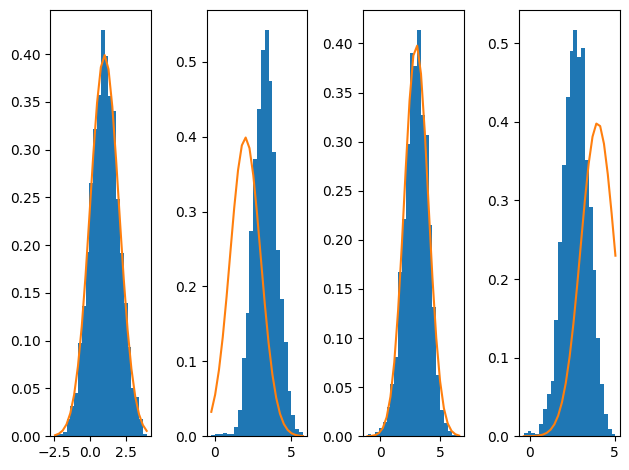

In [3]:
fig, ax = plt.subplots(1,4)
for i in range(4):
    axi = ax[i]
    var = samples_graph.T[i]
    gtm = gt_mean[i]

    x = torch.linspace(var.min(),var.max(),25)
    axi.hist(var.numpy(),density=True,bins=x)
    
    p = torch.exp(gaussian_loglike(x,gtm,torch.tensor(1)))
    axi.plot(x.numpy(),p.numpy())

plt.tight_layout()